In [1]:
import glob
import os
import os.path
import random
import numpy as np
import json
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import zipfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import transforms
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("DEVICE:", DEVICE)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)



DEVICE: cuda
torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


In [2]:
base_dir = "/kaggle/input/dogs-vs-cats-redux-kernels-edition"
work_dir = "/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted"
os.makedirs(work_dir, exist_ok=True)

train_zip_path = os.path.join(base_dir, "train.zip")
test_zip_path = os.path.join(base_dir, "test.zip")

marker_file = os.path.join(work_dir, ".extracted_done")
if not os.path.exists(marker_file):
    with zipfile.ZipFile(train_zip_path) as z:
        z.extractall(work_dir)
    with zipfile.ZipFile(test_zip_path) as z:
        z.extractall(work_dir)
    with open(marker_file, "w") as f:
        f.write("ok")


# Bugfix: the previous directory auto-detection could pick a folder containing mixed files (e.g., numeric ids)
# which breaks label parsing. Instead, explicitly collect train/test jpgs by filename patterns.
def _collect_train_test_lists(extracted_root: str):
    all_jpgs = glob.glob(os.path.join(extracted_root, "**", "*.jpg"), recursive=True)

    train_files = []
    test_files = []

    for p in all_jpgs:
        bn = os.path.basename(p).lower()
        # Train images are named like dog.1234.jpg or cat.5678.jpg
        if bn.startswith("dog.") or bn.startswith("cat."):
            train_files.append(p)
        else:
            # Test images are numeric like 1234.jpg
            stem = os.path.splitext(bn)[0]
            if stem.isdigit():
                test_files.append(p)

    return train_files, test_files


train_list_all, test_list_all = _collect_train_test_lists(work_dir)

print("Found train images:", len(train_list_all))
print("Found test images :", len(test_list_all))

if len(train_list_all) == 0 or len(test_list_all) == 0:
    raise RuntimeError(
        f"Could not find expected images after extraction under {work_dir}. "
        f"Found train={len(train_list_all)} test={len(test_list_all)}."
    )


# Keep a resolved example directory for later visualization (choose the directory that contains most test jpgs).
def _best_parent_dir(file_list):
    counts = {}
    for p in file_list:
        d = os.path.dirname(p)
        counts[d] = counts.get(d, 0) + 1
    return max(counts.items(), key=lambda x: x[1])[0]


train_dir = _best_parent_dir(train_list_all)
test_dir = _best_parent_dir(test_list_all)

print("Resolved train_dir:", train_dir)
print("Resolved test_dir :", test_dir)



Found train images: 22500
Found test images : 2500
Resolved train_dir: /kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted
Resolved test_dir : /kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted


In [3]:
train_list, val_list = train_test_split(
    train_list_all, test_size=0.1, random_state=42, shuffle=True
)

print("Train sample:", train_list[:3])
print("Val sample  :", val_list[:3])
print("Test sample :", test_list_all[:3])




Train sample: ['/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/cat.75.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/dog.8878.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/dog.2345.jpg']
Val sample  : ['/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/cat.10220.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/cat.10110.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/cat.5001.jpg']
Test sample : ['/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/316.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/113.jpg', '/kaggle/working/dogs-vs-cats-redux-kernels-edition-extracted/149.jpg']


In [4]:
class ImageTransform:
    def __init__(self):
        self.data_transform = {
            "train": transforms.Compose(
                [
                    transforms.RandomResizedCrop(224),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                ]
            ),
            "test": transforms.Compose(
                [
                    transforms.Resize(250),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                ]
            ),
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)




In [5]:
class MyDataset(data.Dataset):
    def __init__(self, file_path_list, transform, phase):
        self.file_list = file_path_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path).convert("RGB")
        img_transformed = self.transform(img, self.phase)

        # Bugfix: robust fileid parsing; ensure test id is numeric string (e.g., "1234")
        if self.phase == "test":
            stem = os.path.splitext(os.path.basename(img_path))[0]
            if not stem.isdigit():
                raise ValueError(f"Non-numeric test id parsed from {img_path}: {stem}")
            return img_transformed, stem

        # Train label parsing: dog.123.jpg / cat.456.jpg -> token is "dog" / "cat"
        label_token = os.path.basename(img_path).split(".")[0].lower()
        if label_token == "dog":
            label = 1
        elif label_token == "cat":
            label = 0
        else:
            raise ValueError(f"Unexpected label token parsed from {img_path}")

        return img_transformed, label




In [6]:
transform = ImageTransform()

num_workers = 2

train_dataset = MyDataset(train_list, transform=transform, phase="train")
train_dataloader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

val_dataset = MyDataset(val_list, transform=transform, phase="train")
val_dataloader = data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_dataset = MyDataset(test_list_all, transform=transform, phase="test")
test_dataloader = data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))




Dataset sizes: 20250 2250 2500


In [7]:
class Cnn(nn.Module):
    def __init__(self):
        super(Cnn, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=0, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc1 = nn.Linear(3 * 3 * 64, 10)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(10, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0), -1)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out




In [8]:
model = Cnn()
model.train()
print("Model initialized.")



Model initialized.


In [9]:
from tqdm import tqdm


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    def _train(epoch):
        model.train()
        epoch_loss = 0.0
        epoch_accuracy = 0.0
        with tqdm(train_loader, desc="Training", leave=True) as pbar:
            for batch_data, batch_label in pbar:
                batch_data = batch_data.to(DEVICE)
                batch_label = batch_label.to(DEVICE)

                output = model(batch_data)
                loss = criterion(output, batch_label)

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

                acc = (output.argmax(dim=1) == batch_label).float().mean()
                epoch_accuracy += acc.item() / len(train_loader)
                epoch_loss += loss.item() / len(train_loader)

                pbar.set_postfix(
                    {
                        "Train Loss": epoch_loss,
                        "Train Accuracy": epoch_accuracy,
                        "Learning Rate": optimizer.param_groups[0]["lr"],
                    }
                )

        print(
            f"Epoch: {epoch+1}, Train Accuracy: {epoch_accuracy:.4f}, Train Loss: {epoch_loss:.4f}"
        )

    def _val(epoch):
        model.eval()
        epoch_val_accuracy = 0.0
        epoch_val_loss = 0.0
        with torch.no_grad():
            with tqdm(val_loader, desc="Validation", leave=True) as pbar:
                for batch_data, batch_label in pbar:
                    batch_data = batch_data.to(DEVICE)
                    batch_label = batch_label.to(DEVICE)

                    val_output = model(batch_data)
                    val_loss = criterion(val_output, batch_label)

                    acc = (val_output.argmax(dim=1) == batch_label).float().mean()
                    epoch_val_accuracy += acc.item() / len(val_loader)
                    epoch_val_loss += val_loss.item() / len(val_loader)

                    pbar.set_postfix(
                        {"Val Loss": epoch_val_loss, "Val Accuracy": epoch_val_accuracy}
                    )

        print(
            f"Epoch: {epoch+1}, Validation Accuracy: {epoch_val_accuracy:.4f}, Validation Loss: {epoch_val_loss:.4f}"
        )

    model = model.to(DEVICE)
    _val(-1)

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        _train(epoch)
        _val(epoch)




In [10]:
optimizer = optim.Adam(params=model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()



In [11]:
train_model(model, train_dataloader, val_dataloader, optimizer, criterion, 10)



Validation: 100%|██████████| 18/18 [00:02<00:00,  6.01it/s, Val Loss=0.693, Val Accuracy=0.505]


Epoch: 0, Validation Accuracy: 0.5047, Validation Loss: 0.6932
Epoch 1/10


Training: 100%|██████████| 159/159 [00:22<00:00,  7.19it/s, Train Loss=0.637, Train Accuracy=0.634, Learning Rate=0.0005]


Epoch: 1, Train Accuracy: 0.6337, Train Loss: 0.6374


Validation: 100%|██████████| 18/18 [00:02<00:00,  6.62it/s, Val Loss=0.605, Val Accuracy=0.678]


...

Epoch: 9, Validation Accuracy: 0.7016, Validation Loss: 0.6290
Epoch 10/10


Training: 100%|██████████| 159/159 [00:21<00:00,  7.31it/s, Train Loss=0.478, Train Accuracy=0.765, Learning Rate=0.0005]


Epoch: 10, Train Accuracy: 0.7652, Train Loss: 0.4775


Validation: 100%|██████████| 18/18 [00:02<00:00,  6.49it/s, Val Loss=0.47, Val Accuracy=0.776]

Epoch: 10, Validation Accuracy: 0.7764, Validation Loss: 0.4695


In [12]:
dog_probs = []
model.eval()
with torch.no_grad():
    for batch_data, batch_fileid in tqdm(test_dataloader, desc="Inference", leave=True):
        batch_data = batch_data.to(DEVICE)
        preds = model(batch_data)
        preds_list = F.softmax(preds, dim=1)[:, 1].detach().cpu().numpy().tolist()
        dog_probs += list(zip(list(batch_fileid), preds_list))

# Bugfix: fileid is guaranteed numeric string now; sorting will work.
dog_probs.sort(key=lambda x: int(x[0]))
print("First preds:", dog_probs[:5])



Inference: 100%|██████████| 20/20 [00:03<00:00,  5.76it/s]

First preds: [('1', 0.9651273488998413), ('2', 0.12063973397016525), ('3', 0.011800731532275677), ('4', 0.8024773597717285), ('5', 0.10840284079313278)]


In [13]:
sample_path = os.path.join(base_dir, "sample_submission.csv")
sample = pd.read_csv(sample_path)
sample["id"] = sample["id"].astype(int)

# Bugfix: robust mapping; dog_probs keys are numeric strings => int conversion OK.
pred_map = {int(fid): float(p) for fid, p in dog_probs}

labels = [pred_map.get(int(i), 0.5) for i in sample["id"].tolist()]
submission = pd.DataFrame({"id": sample["id"].tolist(), "label": labels})

assert list(submission.columns) == [
    "id",
    "label",
], "Submission columns must be id,label"
assert submission["id"].is_unique, "Duplicate ids in submission"
assert len(submission) == len(sample), "Row count mismatch vs sample_submission"
assert submission["label"].between(0.0, 1.0).all(), "Probabilities must be in [0,1]"

print(submission.head())
print(
    "Submission rows:",
    len(submission),
    "id min/max:",
    submission["id"].min(),
    submission["id"].max(),
)



   id     label
0   1  0.965127
1   2  0.120640
2   3  0.011801
3   4  0.802477
4   5  0.108403
Submission rows: 2500 id min/max: 1 2500


In [14]:
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv")



Wrote submission.csv


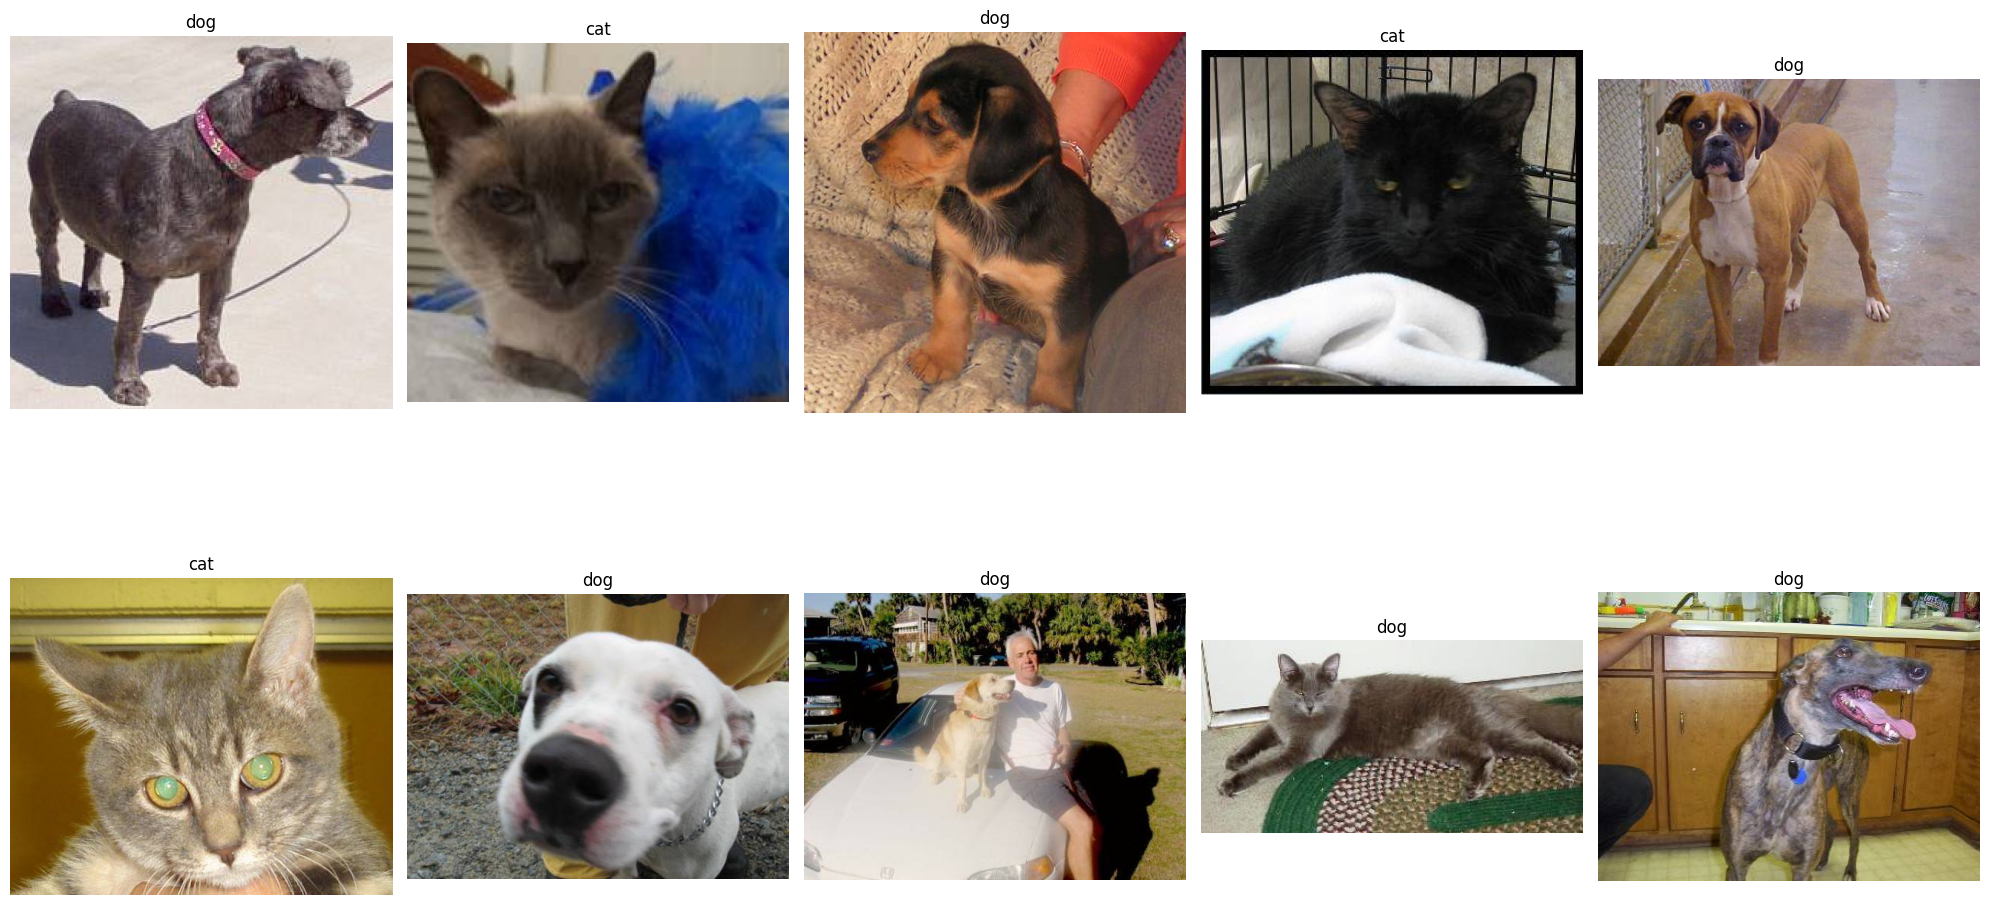

In [15]:
if len(submission) > 0:
    class_ = {0: "cat", 1: "dog"}

    fig, axes = plt.subplots(2, 5, figsize=(20, 12), facecolor="w")

    for ax in axes.ravel():
        i = int(random.choice(submission["id"].values))
        label_prob = submission.loc[submission["id"] == i, "label"].values[0]
        label = 1 if label_prob > 0.5 else 0

        img_path = os.path.join(test_dir, f"{i}.jpg")
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.set_title(class_[label])
            ax.imshow(img)
            ax.axis("off")
        else:
            ax.set_title(f"missing {i}.jpg")
            ax.axis("off")
    plt.tight_layout()